In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print(" All imports ready!")

 All imports ready!


In [2]:

df = pd.read_csv('AB_NYC_2019.csv')
print(f"Dataset loaded! Shape: {df.shape}")
df.head()

Dataset loaded! Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print("=== BEFORE CLEANING ===")
print(f"Rows: {df.shape[0]}")
print(f"Missing values:\n{df.isnull().sum()}")

# Drop rows where price is missing (essential for prediction)
df = df.dropna(subset=['price'])

# Fill missing reviews_per_month with 0 (no reviews)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Fill missing host_name with 'Unknown'
df['host_name'] = df['host_name'].fillna('Unknown')

# Fill missing last_review with most common date
df['last_review'] = df['last_review'].fillna(df['last_review'].mode()[0])

# Drop rows with missing name (not essential, but let's drop them)
df = df.dropna(subset=['name'])

# Drop ID columns (not useful for prediction)
df = df.drop(['id', 'host_id', 'host_name'], axis=1)

print("\n=== AFTER CLEANING ===")
print(f"Rows: {df.shape[0]}")
print(f"Missing values:\n{df.isnull().sum()}")

=== BEFORE CLEANING ===
Rows: 48895
Missing values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

=== AFTER CLEANING ===
Rows: 48879
Missing values:
name                              0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                      

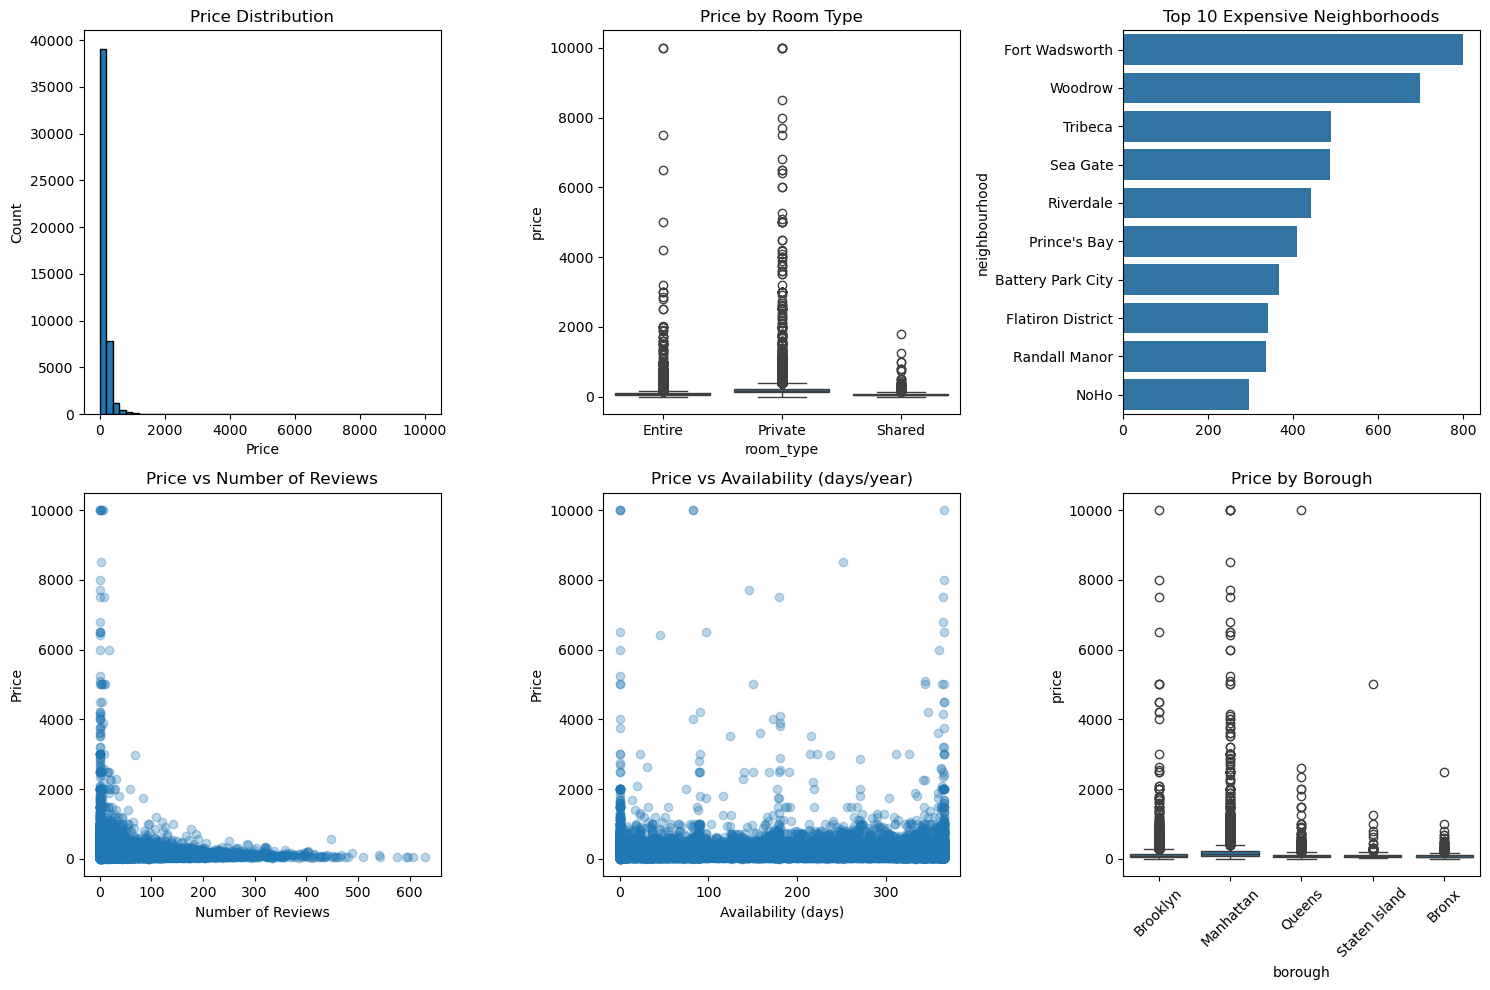


=== PRICE STATISTICS ===
Mean Price: $152.72
Median Price: $106.00
Max Price: $10000.00
Min Price: $0.00


In [4]:
# --- Price Distribution ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Price distribution
axes[0, 0].hist(df['price'], bins=50, edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Count')

# 2. Price by Room Type
sns.boxplot(data=df, x='room_type', y='price', ax=axes[0, 1])
axes[0, 1].set_title('Price by Room Type')
axes[0, 1].set_xticklabels(['Entire', 'Private', 'Shared'])

# 3. Price by Neighborhood
top_neighborhoods = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, ax=axes[0, 2])
axes[0, 2].set_title('Top 10 Expensive Neighborhoods')

# 4. Price vs Reviews
axes[1, 0].scatter(df['number_of_reviews'], df['price'], alpha=0.3)
axes[1, 0].set_title('Price vs Number of Reviews')
axes[1, 0].set_xlabel('Number of Reviews')
axes[1, 0].set_ylabel('Price')

# 5. Price vs Availability
axes[1, 1].scatter(df['availability_365'], df['price'], alpha=0.3)
axes[1, 1].set_title('Price vs Availability (days/year)')
axes[1, 1].set_xlabel('Availability (days)')
axes[1, 1].set_ylabel('Price')

# 6. Price by Borough
df['borough'] = df['neighbourhood_group']
sns.boxplot(data=df, x='borough', y='price', ax=axes[1, 2])
axes[1, 2].set_title('Price by Borough')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# --- Summary Statistics ---
print("\n=== PRICE STATISTICS ===")
print(f"Mean Price: ${df['price'].mean():.2f}")
print(f"Median Price: ${df['price'].median():.2f}")
print(f"Max Price: ${df['price'].max():.2f}")
print(f"Min Price: ${df['price'].min():.2f}")

In [5]:
# --- Create New Features ---

# 1. Price per night (already have price)

# 2. Days since last review
from datetime import datetime
df['last_review'] = pd.to_datetime(df['last_review'])
df['days_since_review'] = (pd.Timestamp.now() - df['last_review']).dt.days

# 3. Popularity score (reviews + availability combined)
df['popularity_score'] = df['number_of_reviews'] / (df['availability_365'] + 1)

# 4. Is superhost (if reviews > 50, flag as superhost)
df['is_superhost'] = (df['number_of_reviews'] > 50).astype(int)

# 5. Neighborhood group as categorical (already have neighbourhood_group)

print(" Feature engineering complete!")

# Select features for modeling
features = ['neighbourhood_group', 'room_type', 'latitude', 'longitude', 
            'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365', 
            'days_since_review', 'popularity_score', 'is_superhost']

X = df[features]
y = df['price']

print(f"Features shape: {X.shape}")
print(f"Features: {list(X.columns)}")

 Feature engineering complete!
Features shape: (48879, 12)
Features: ['neighbourhood_group', 'room_type', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_review', 'popularity_score', 'is_superhost']


In [6]:
# --- Encode categorical variables ---
X = pd.get_dummies(X, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# --- Remove outliers (price > 1000) ---
print(f"Before outlier removal: {X.shape[0]} rows")
outlier_mask = y <= 1000
X = X[outlier_mask]
y = y[outlier_mask]
print(f"After outlier removal: {X.shape[0]} rows")

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Scale numerical features ---
scaler = StandardScaler()
numeric_cols = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 
                'reviews_per_month', 'calculated_host_listings_count', 
                'availability_365', 'days_since_review', 'popularity_score']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Before outlier removal: 48879 rows
After outlier removal: 48640 rows
Training set: 38912 rows
Test set: 9728 rows


In [7]:
# --- Define models ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

# --- Train and evaluate ---
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'R² Score': r2,
        'MAE': mae
    })
    
    print(f"{name} - RMSE: ${rmse:.2f}, R²: {r2:.4f}, MAE: ${mae:.2f}")

# --- Comparison DataFrame ---
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))

Linear Regression - RMSE: $95.93, R²: 0.3239, MAE: $56.59
Ridge Regression - RMSE: $95.93, R²: 0.3239, MAE: $56.58
Lasso Regression - RMSE: $95.93, R²: 0.3239, MAE: $56.58
Random Forest - RMSE: $86.57, R²: 0.4494, MAE: $49.35
Gradient Boosting - RMSE: $88.93, R²: 0.4190, MAE: $50.58
XGBoost - RMSE: $86.24, R²: 0.4536, MAE: $49.17

=== MODEL COMPARISON ===
            Model      RMSE  R² Score       MAE
          XGBoost 86.242357  0.453588 49.167455
    Random Forest 86.568308  0.449449 49.351529
Gradient Boosting 88.932953  0.418962 50.576149
 Ridge Regression 95.932159  0.323905 56.582612
 Lasso Regression 95.932665  0.323898 56.584268
Linear Regression 95.932991  0.323893 56.585704


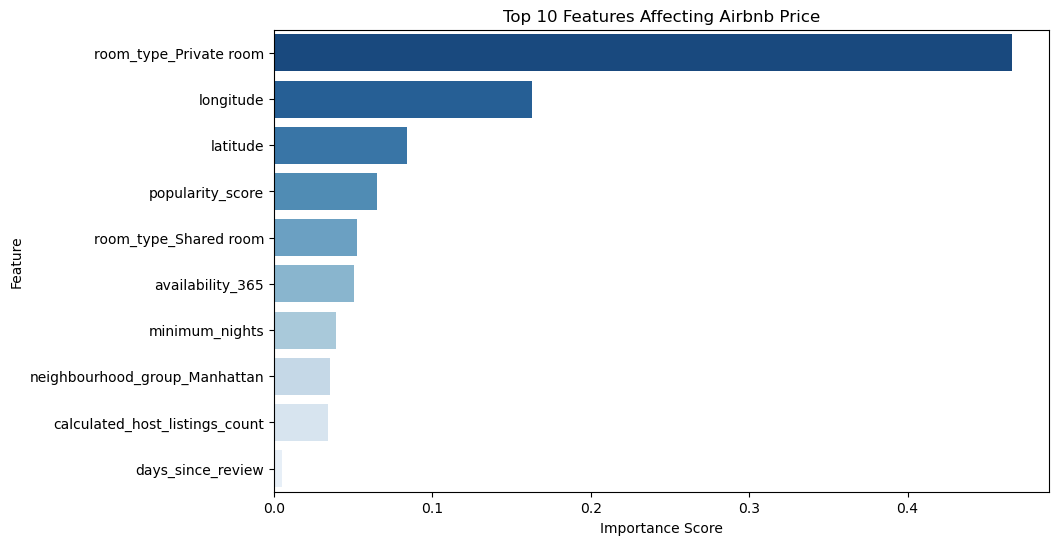


=== TOP 5 IMPORTANT FEATURES ===
                   Feature  Importance
14  room_type_Private room    0.465840
1                longitude    0.162671
0                 latitude    0.083713
8         popularity_score    0.065019
15   room_type_Shared room    0.052626


In [8]:
# --- Pick best model (Gradient Boosting or Random Forest) ---
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# --- Feature importance ---
importances = best_model.feature_importances_
feature_names = X.columns

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Blues_r', hue='Feature', legend=False)
plt.title('Top 10 Features Affecting Airbnb Price')
plt.xlabel('Importance Score')
plt.show()

print("\n=== TOP 5 IMPORTANT FEATURES ===")
print(imp_df.head(5))

In [9]:
import joblib

# Save best model, scaler, and feature names
joblib.dump(best_model, 'airbnb_price_model.pkl')
joblib.dump(scaler, 'airbnb_scaler.pkl')
joblib.dump(X.columns.tolist(), 'airbnb_features.pkl')

print(" Model saved successfully!")
print(f"Model type: {type(best_model).__name__}")
print(f"Features: {len(X.columns)}")

 Model saved successfully!
Model type: GradientBoostingRegressor
Features: 16


In [2]:
import os

# Check if model files exist
print("Files in current folder:")
for f in os.listdir():
    if f.endswith('.pkl'):
        print(f"  - {f}")

if os.path.exists('airbnb_price_model.pkl'):
    import joblib
    best_model = joblib.load('airbnb_price_model.pkl')
    scaler = joblib.load('airbnb_scaler.pkl')
    print(" Model loaded from joblib!")

Files in current folder:
  - airbnb_features.pkl
  - model.pkl
  - scaler.pkl


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
import joblib

# Load your dataset
df = pd.read_csv('AB_NYC_2019.csv')  # or whatever your filename is

# Clean data
df = df.dropna(subset=['price'])
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df.dropna(subset=['name'])
df = df.drop(['id', 'host_id', 'host_name', 'name', 'last_review'], axis=1, errors='ignore')

# Feature engineering
df['days_since_review'] = 30  # placeholder
df['popularity_score'] = df['number_of_reviews'] / (df['availability_365'] + 1)
df['is_superhost'] = (df['number_of_reviews'] > 50).astype(int)

# Features and target
features = ['neighbourhood_group', 'room_type', 'latitude', 'longitude', 
            'minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365', 
            'days_since_review', 'popularity_score', 'is_superhost']

X = df[features]
y = df['price']

# One-hot encode
X = pd.get_dummies(X, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# Remove outliers
mask = y <= 1000
X = X[mask]
y = y[mask]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
numeric_cols = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 
                'reviews_per_month', 'calculated_host_listings_count', 
                'availability_365', 'days_since_review', 'popularity_score']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Train
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

print(" Model retrained successfully!")

 Model retrained successfully!


In [5]:
import pickle

# Save with pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f, protocol=pickle.HIGHEST_PROTOCOL)

print(" Model and scaler saved with pickle!")

 Model and scaler saved with pickle!
